In [7]:
# Cell 2
import torch
import numpy as np
import pandas as pd
import faiss
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Configuration for Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Model IDs
MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.3" 
EMBED_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"
DATASET_ID = "mteb/scifact"

print("Libraries loaded. Config set.")

Libraries loaded. Config set.


In [11]:
class KnowledgeBase:
    def __init__(self, dataset_name, embedding_model_name):
        print(f"Loading Dataset: {dataset_name}...")

        # Preferred path for mteb/scifact corpus view
        # (config='corpus', split='corpus' in this dataset layout)
        try:
            self.corpus = load_dataset(dataset_name, "corpus", split="corpus")
        except Exception:
            # Fallback for alternate dataset layouts
            ds = load_dataset(dataset_name)
            if "corpus" in ds:
                self.corpus = ds["corpus"]
            elif "train" in ds:
                self.corpus = ds["train"]
            else:
                self.corpus = ds[list(ds.keys())[0]]

        # Extract text for indexing
        # Supports both schemas:
        # 1) allenai/scifact: {'doc_id': int, 'title': str, 'abstract': list[str]}
        # 2) mteb/scifact: {'corpus-id': str, 'title': str, 'text': str}
        self.docs = []
        self.doc_ids = []

        print("Processing corpus...")
        for row in tqdm(self.corpus):
            if "abstract" in row:
                text = " ".join(row["abstract"])  # list[str]
                doc_id = row.get("doc_id")
            else:
                title = row.get("title", "")
                body = row.get("text", "")
                text = f"{title} {body}".strip()
                doc_id = row.get("corpus-id", row.get("doc_id"))

            if len(text) > 20:
                self.docs.append(text)
                self.doc_ids.append(doc_id)

        # Initialize Embedder
        print("Loading Embedder...")
        self.embedder = SentenceTransformer(embedding_model_name, device="cuda")

        # Create Index
        print("Encoding Corpus (this takes a moment)...")
        embeddings = self.embedder.encode(self.docs, convert_to_numpy=True, normalize_embeddings=True)

        # FAISS Index
        d = embeddings.shape[1]
        self.index = faiss.IndexFlatIP(d)  # Inner Product (Cosine Similarity)
        self.index.add(embeddings)
        print(f"Index built with {self.index.ntotal} documents.")

    def retrieve(self, query, k=3):
        q_emb = self.embedder.encode([query], convert_to_numpy=True, normalize_embeddings=True)
        scores, indices = self.index.search(q_emb, k)
        return [self.docs[i] for i in indices[0]]

# Initialize KB
kb = KnowledgeBase(DATASET_ID, EMBED_MODEL_ID)

Loading Dataset: mteb/scifact...
Processing corpus...


  0%|          | 0/5183 [00:00<?, ?it/s]

Loading Embedder...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding Corpus (this takes a moment)...
Index built with 5183 documents.


In [12]:
# Cell 4
# 4-bit Quantization Config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("Loading LLM (4-bit)...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Model loaded successfully.")

Loading LLM (4-bit)...


config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded successfully.


In [26]:
# Cell 5
def calculate_token_entropy(logits):
    """
    Calculates entropy from raw logits.
    H(x) = - sum(p(x) * log(p(x)))
    """
    probs = torch.softmax(logits, dim=-1)
    log_probs = torch.log_softmax(logits, dim=-1)
    entropy = -torch.sum(probs * log_probs, dim=-1)
    return torch.mean(entropy).item()

def get_semantic_uncertainty(answers, embedder):
    """
    Calculates semantic variance between generated samples.
    Fixes the 'diagonal bias' by masking self-similarity.
    """
    if len(answers) < 2:
        return 0.0
        
    embeddings = embedder.encode(answers, normalize_embeddings=True)
    sim_matrix = embeddings @ embeddings.T
    
    # Mask diagonal (self-similarity is always 1.0)
    mask = ~np.eye(sim_matrix.shape[0], dtype=bool)
    
    # Mean dissimilarity (1 - similarity) of off-diagonal elements
    mean_similarity = sim_matrix[mask].mean()
    return 1.0 - mean_similarity

In [35]:
# Cell 6
def run_rag_benchmark(limit=20, start_idx=0):
    results = []

    # Get evaluation data directly from dataset (KB only stores retrieval corpus)
    try:
        test_data = load_dataset(DATASET_ID, split="test")
        chosen_split = "test"
    except Exception:
        ds = load_dataset(DATASET_ID)
        for split_name in ["test", "validation", "dev", "train"]:
            if split_name in ds:
                test_data = ds[split_name]
                chosen_split = split_name
                break
        else:
            chosen_split = list(ds.keys())[0]
            test_data = ds[chosen_split]

    print(
        f"Running Benchmark on {limit} samples from split='{chosen_split}' starting at index {start_idx}..."
    )

    collected = 0
    for i, row in tqdm(enumerate(test_data), total=start_idx + limit):
        if i < start_idx:
            continue
        if collected >= limit:
            break

        # Try common field names first
        claim = (
            row.get("claim")
            or row.get("query")
            or row.get("text")
            or row.get("sentence")
        )

        # Fallback: use first non-empty string field in the row
        if not isinstance(claim, str) or not claim.strip():
            claim = None
            for _, v in row.items():
                if isinstance(v, str) and v.strip():
                    claim = v
                    break

        if not claim:
            continue

        # 1. Retrieve
        context_docs = kb.retrieve(claim, k=3)
        context_text = "\n".join([f"- {d}" for d in context_docs])

        # 2. Build Prompt
        messages = [
            {
                "role": "user",
                "content": f"""Context:
{context_text}

Claim: {claim}
Is this claim supported or refuted by the context? Answer strictly 'Supported', 'Refuted', or 'Not Enough Info' followed by a short explanation.""",
            }
        ]

        model_inputs = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt",
            return_dict=True,
        ).to("cuda")

        with torch.no_grad():
            outputs = model.generate(
                **model_inputs,
                max_new_tokens=100,
                output_scores=True,
                return_dict_in_generate=True,
                do_sample=False,
            )

        generated_tokens = outputs.sequences[0][len(model_inputs["input_ids"][0]) :]
        answer_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)

        logits = torch.stack(outputs.scores, dim=1)
        entropy_score = calculate_token_entropy(logits)

        sample_answers = [answer_text]
        for _ in range(3):
            with torch.no_grad():
                out_sample = model.generate(
                    **model_inputs, max_new_tokens=100, do_sample=True, temperature=0.7
                )
                sample_text = tokenizer.decode(
                    out_sample[0][len(model_inputs["input_ids"][0]) :], skip_special_tokens=True
                )
                sample_answers.append(sample_text)

        semantic_score = get_semantic_uncertainty(sample_answers, kb.embedder)

        results.append(
            {
                "claim": claim,
                # "label": row['label'],
                "context": context_text[:100] + "...",
                "answer": answer_text,
                "entropy": entropy_score,
                "semantic_uncertainty": semantic_score,
            }
        )
        collected += 1

    if len(results) == 0:
        return pd.DataFrame(
            columns=["claim", "context", "answer", "entropy", "semantic_uncertainty"]
        )

    return pd.DataFrame(results)

In [36]:
# Cell 7 (50-sample run with checkpoints)
total_samples = 50
batch_size = 10
checkpoint_path = "rag_benchmark_progress.csv"

parts = []
for start in range(0, total_samples, batch_size):
    current_limit = min(batch_size, total_samples - start)
    print(f"\nBatch starting at {start} (size={current_limit})")
    batch_df = run_rag_benchmark(limit=current_limit, start_idx=start)
    parts.append(batch_df)

    progress_df = pd.concat(parts, ignore_index=True)
    progress_df.to_csv(checkpoint_path, index=False)
    print(f"Saved {len(progress_df)} rows to {checkpoint_path}")

df_results = pd.concat(parts, ignore_index=True)
print("\nFinal rows:", len(df_results))
df_results.head()


Batch starting at 0 (size=10)
Running Benchmark on 10 samples from split='test' starting at index 0...


  0%|          | 0/10 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Saved 10 rows to rag_benchmark_progress.csv

Batch starting at 10 (size=10)
Running Benchmark on 10 samples from split='test' starting at index 10...


  0%|          | 0/20 [00:00<?, ?it/s]

...

Saved 40 rows to rag_benchmark_progress.csv

Batch starting at 40 (size=10)
Running Benchmark on 10 samples from split='test' starting at index 40...


  0%|          | 0/50 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Saved 50 rows to rag_benchmark_progress.csv

Final rows: 50


,claim,context,answer,entropy,semantic_uncertainty
0,1,"- ANKTM1, a TRP-like Channel Expressed in Noci...",Supported\n\nThe context describes the charact...,0.313551,0.064679
1,3,- Multiple Imputation For Nonresponse In Surve...,Supported\n\nThe claim is supported by the con...,0.323465,0.123039
2,5,- Immediate effects of droperidol The subjecti...,Supported\n\nExplanation: The context discusse...,0.323077,0.090725
3,13,- Bullying in school: are short pupils at risk...,Supported\n\nThe context discusses a study tha...,0.430400,0.492541
4,36,- p16INK4A is a robust in vivo biomarker of ce...,Supported\n\nThe context provides evidence tha...,0.213959,0.037687


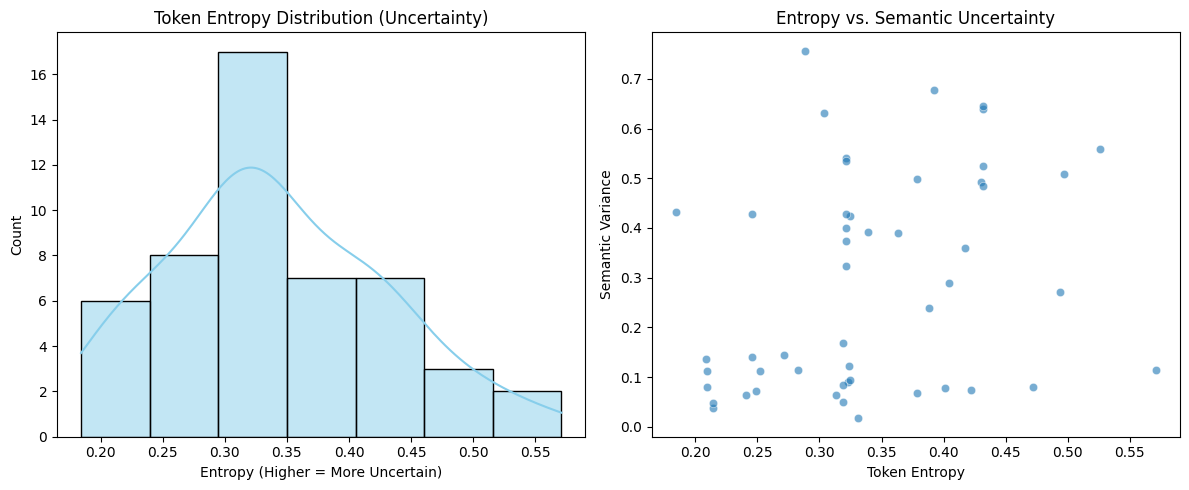

Results saved.


In [37]:
# Cell 7
# Visualization
plt.figure(figsize=(12, 5))

# Plot 1: Entropy Distribution
plt.subplot(1, 2, 1)
sns.histplot(df_results['entropy'], kde=True, color='skyblue')
plt.title('Token Entropy Distribution (Uncertainty)')
plt.xlabel('Entropy (Higher = More Uncertain)')

# Plot 2: Semantic Uncertainty vs Entropy
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_results, x='entropy', y='semantic_uncertainty', alpha=0.6)
plt.title('Entropy vs. Semantic Uncertainty')
plt.xlabel('Token Entropy')
plt.ylabel('Semantic Variance')

plt.tight_layout()
plt.show()

# Save results for your paper
df_results.to_csv("rag_uncertainty_benchmark.csv", index=False)
print("Results saved.")

In [38]:
# Filter for "Confident Hallucinations" (Low Entropy, High Semantic Uncertainty)
danger_zone = df_results[
    (df_results['entropy'] < 0.35) & 
    (df_results['semantic_uncertainty'] > 0.4)
]

print(f"Found {len(danger_zone)} danger zone examples.")

for i, row in danger_zone.iterrows():
    print(f"\n--- Danger Zone Example {i} ---")
    print(f"Claim: {row['claim']}")
    print(f"Entropy (Low): {row['entropy']:.4f}")
    print(f"Semantic Unc (High): {row['semantic_uncertainty']:.4f}")
    print(f"Answer: {row['answer']}")
    # If you saved the sample answers in your dataframe, print them too to see the conflict!

Found 8 danger zone examples.

--- Danger Zone Example 7 ---
Claim: 48
Entropy (Low): 0.1842
Semantic Unc (High): 0.4328
Answer: Supported

The claim is that memory deficits in middle-aged Tg2576 mice are caused by the extracellular accumulation of a 56-kDa soluble amyloid-β assembly, which they term Aβ*56. This is supported by the context as it is stated that middle-aged Tg2576 mice (6–14 months old) develop memory deficits without neuronal

--- Danger Zone Example 16 ---
Claim: 70
Entropy (Low): 0.2461
Semantic Unc (High): 0.4287
Answer: Supported

The context discusses the incidence of dementia in middle-income countries, and it is stated that the incidence of 10/66 dementia varied between 18.2 and 30.4 per 1000 person-years, and were 1.4-2.7 times higher than were those for DSM-IV dementia (9.9-15.7 per 10

--- Danger Zone Example 19 ---
Claim: 94
Entropy (Low): 0.3036
Semantic Unc (High): 0.6318
Answer: Supported

The context discusses the Foodborne-Disease Outbreak Surveillance S